# Matplotlib 시각화 실습: 라인, 바, 히스토그램, 산점도, 원형 차트, 히트맵

## 실습 개요

이 노트북은 기존 실습 데이터 중 **`stock_px.csv`**와 **`iris.data`**를 사용하여 Matplotlib의 대표 그래프를 실습합니다.

| 그래프 | 사용하는 데이터 | 핵심 의미 |
|---|---|---|
| 라인 그래프 | `stock_px.csv` | 시간 순서에 따른 값의 변화와 추세 확인 |
| 바 그래프 | `iris.data` | 범주별 크기 비교 |
| 히스토그램 | `iris.data` | 하나의 수치형 변수의 분포 확인 |
| 산점도 | `iris.data` | 두 수치형 변수 사이의 관계 확인 |
| 원형 차트 | `iris.data` | 전체에서 각 범주가 차지하는 비율 확인 |
| 히트맵 | `iris.data` | 2차원 행렬 값, 특히 상관관계 구조 확인 |

> 실습 목적은 그래프를 단순히 그리는 것이 아니라, **어떤 상황에서 어떤 그래프를 선택해야 하는지**를 이해하는 것입니다.

## 1. 실습 환경 준비

Matplotlib은 가장 기본적이고 범용적인 Python 시각화 도구입니다. Pandas의 `plot()` 메서드도 내부적으로 Matplotlib을 활용하는 경우가 많습니다.

In [1]:
# Jupyter Notebook 안에서 그래프를 바로 표시하기 위한 매직 명령어입니다.
%matplotlib inline

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ------------------------------------------------------------
# 한글 폰트 설정
# ------------------------------------------------------------
# 의미:
# - 그래프 제목, 축 이름, 범례에 한글을 쓰면 운영체제/실행환경에 따라 글자가 깨질 수 있습니다.
# - 아래 코드는 가능한 한글 폰트를 자동 탐색하여 설정합니다.
# - 사용 가능한 한글 폰트가 없으면 기본 폰트로 진행합니다.
# ------------------------------------------------------------

candidate_fonts = [
    "Malgun Gothic",      # Windows
    "AppleGothic",       # macOS
    "NanumGothic",       # Linux / Colab
    "Noto Sans CJK KR",   # Linux
    "Noto Sans KR"
]

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in available_fonts:
        rcParams["font.family"] = font_name
        break

# 마이너스 기호가 깨지는 문제를 방지합니다.
rcParams["axes.unicode_minus"] = False

# 그래프 크기와 격자 기본값을 설정합니다.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Matplotlib version:", plt.matplotlib.__version__)
print("Pandas version:", pd.__version__)
print("현재 설정된 폰트:", rcParams.get("font.family"))

Matplotlib version: 3.10.6
Pandas version: 2.3.3
현재 설정된 폰트: ['Malgun Gothic']


## 2. 데이터 불러오기

이번 실습에서는 두 개의 기존 데이터를 사용합니다.

### 2.1 `stock_px.csv`
- 날짜별 주가 또는 지수 가격 데이터입니다.
- 시간 순서가 중요하므로 **라인 그래프** 실습에 적합합니다.

### 2.2 `iris.data`
- 붓꽃의 꽃받침/꽃잎 길이와 너비, 품종 정보가 들어 있는 대표적인 분류 실습 데이터입니다.
- 범주형 변수(`species`)와 수치형 변수들이 함께 있어 **바 그래프, 히스토그램, 산점도, 원형 차트, 히트맵** 실습에 적합합니다.

In [2]:
# ------------------------------------------------------------
# 데이터 경로 설정
# ------------------------------------------------------------
# 의미:
# - ChatGPT 실행 환경에서는 보통 /mnt/data 아래에 파일이 있습니다.
# - 사용자가 로컬 PC에서 실행할 경우, 노트북 파일과 같은 폴더에 데이터 파일을 두면 됩니다.
# ------------------------------------------------------------

def find_data_file(filename):
    candidates = [
        Path(filename),
        Path("./data") / filename,
        Path("/mnt/data") / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"{filename} 파일을 찾을 수 없습니다. 노트북과 같은 폴더 또는 /mnt/data에 파일을 두세요."
    )

stock_path = find_data_file("stock_px.csv")
iris_path = find_data_file("iris.data")

print("stock_px.csv 경로:", stock_path)
print("iris.data 경로:", iris_path)

stock_px.csv 경로: data\stock_px.csv
iris.data 경로: data\iris.data


In [3]:
# ------------------------------------------------------------
# stock_px.csv 불러오기
# ------------------------------------------------------------
# 의미:
# - 첫 번째 열을 날짜 인덱스로 사용합니다.
# - parse_dates=True를 사용하여 문자열 날짜를 datetime 형식으로 변환합니다.
# ------------------------------------------------------------

stock = pd.read_csv(stock_path, index_col=0, parse_dates=True)

print("stock 데이터 크기:", stock.shape)
display(stock.head())
display(stock.tail())

stock 데이터 크기: (2214, 4)


,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93


,AAPL,MSFT,XOM,SPX
2011-10-10,388.81,26.94,76.28,1194.89
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66
2011-10-14,422.00,27.27,78.11,1224.58


In [4]:
# ------------------------------------------------------------
# iris.data 불러오기
# ------------------------------------------------------------
# 의미:
# - iris.data는 보통 컬럼명이 없는 CSV 형태입니다.
# - 분석하기 쉽도록 직접 컬럼명을 부여합니다.
# ------------------------------------------------------------

iris_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

iris = pd.read_csv(iris_path, header=None, names=iris_columns)

print("iris 데이터 크기:", iris.shape)
display(iris.head())
display(iris.tail())

iris 데이터 크기: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


## 3. 데이터 기본 확인

시각화 전에 데이터의 구조를 확인해야 합니다. 시각화는 데이터를 보기 좋게 만드는 작업이 아니라, **데이터의 구조와 질문에 맞는 그래프를 선택하는 작업**입니다.

In [5]:
# stock 데이터 기본 정보
print("[stock 데이터 정보]")
stock.info()
display(stock.describe())

# iris 데이터 기본 정보
print("\n[iris 데이터 정보]")
iris.info()
display(iris.describe())
display(iris["species"].value_counts())

[stock 데이터 정보]
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2214 entries, 2003-01-02 to 2011-10-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2214 non-null   float64
 1   MSFT    2214 non-null   float64
 2   XOM     2214 non-null   float64
 3   SPX     2214 non-null   float64
dtypes: float64(4)
memory usage: 86.5 KB


,AAPL,MSFT,XOM,SPX
count,2214.000000,2214.000000,2214.000000,2214.000000
mean,125.516147,23.945452,59.558744,1183.773311
std,107.394693,3.255198,16.725025,180.983466
min,6.560000,14.330000,26.210000,676.530000
25%,37.135000,21.700000,49.492500,1077.060000
50%,91.455000,24.000000,62.970000,1189.260000
75%,185.605000,26.280000,72.510000,1306.057500
max,422.000000,34.070000,87.480000,1565.150000



[iris 데이터 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# 4. 라인 그래프(Line Plot)

## 의미

라인 그래프는 **X축의 값이 순서 또는 시간의 흐름을 가질 때** 유용합니다.

예를 들어 날짜가 변함에 따라 주가가 어떻게 움직이는지, 월별 매출이 어떻게 증가 또는 감소하는지를 확인할 때 사용합니다.

이번 실습에서는 `stock_px.csv`의 날짜별 가격 데이터를 사용합니다.

C:\Users\yhkim\AppData\Local\Temp\ipykernel_12428\1314002929.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stock_monthly = stock.resample("M").mean()


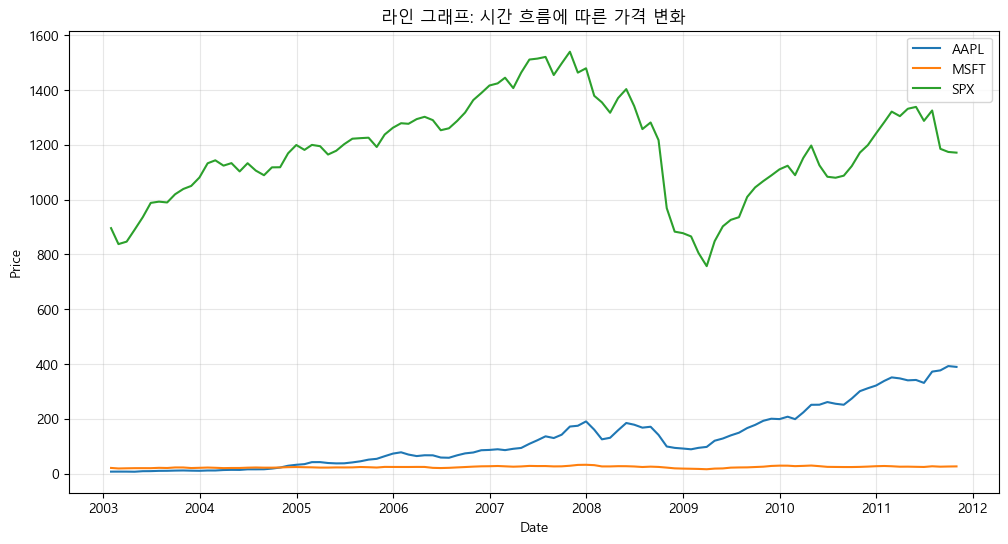

In [6]:
# ------------------------------------------------------------
# 라인 그래프: 시간 흐름에 따른 가격 변화 확인
# ------------------------------------------------------------
# 의미:
# - 라인 그래프는 특정 독립변수 X가 변화함에 따라 종속변수 Y가 어떻게 변화하는지 볼 때 사용합니다.
# - 여기서는 X축이 날짜, Y축이 주가/지수 가격입니다.
# - 날짜처럼 순서가 중요한 데이터는 막대그래프보다 라인 그래프가 추세 파악에 적합합니다.
# ------------------------------------------------------------

# 데이터가 너무 길 경우 그래프가 복잡할 수 있으므로 월별 평균으로 변환합니다.
stock_monthly = stock.resample("M").mean()

# 일부 컬럼만 선택하여 시각화합니다.
line_cols = [col for col in ["AAPL", "MSFT", "SPX"] if col in stock_monthly.columns]
if len(line_cols) == 0:
    line_cols = stock_monthly.columns[:3].tolist()

plt.figure(figsize=(12, 6))
for col in line_cols:
    plt.plot(stock_monthly.index, stock_monthly[col], label=col)

plt.title("라인 그래프: 시간 흐름에 따른 가격 변화")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 라인 그래프 해석 질문

1. 어떤 종목 또는 지수가 가장 큰 폭으로 변화했나요?
2. 특정 시점 이후 상승 또는 하락 추세가 뚜렷하게 보이나요?
3. 라인 그래프가 바 그래프보다 이 데이터에 적합한 이유는 무엇인가요?

# 5. 바 그래프(Bar Plot)

## 의미

바 그래프는 **범주별 값을 비교**할 때 유용합니다.

예를 들어 품종별 평균 꽃잎 길이, 자치구별 CCTV 수, 부서별 매출액처럼 각 범주가 서로 독립적이고 크기를 비교하고 싶을 때 사용합니다.

이번 실습에서는 `iris.data`의 품종별 평균 꽃잎 길이를 비교합니다.

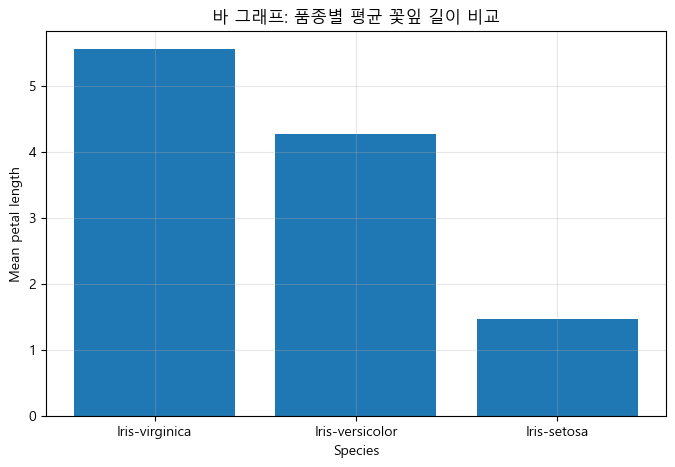

,mean_petal_length
species,
Iris-virginica,5.552
Iris-versicolor,4.260
Iris-setosa,1.464


In [7]:
# ------------------------------------------------------------
# 바 그래프: 범주별 평균값 비교
# ------------------------------------------------------------
# 의미:
# - 바 그래프는 카테고리별 크기 비교에 적합합니다.
# - 여기서는 품종(species)별 평균 꽃잎 길이(petal_length)를 비교합니다.
# - x축은 범주형 변수, y축은 비교하고자 하는 수치형 변수입니다.
# ------------------------------------------------------------

species_petal_mean = iris.groupby("species")["petal_length"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(species_petal_mean.index, species_petal_mean.values)

plt.title("바 그래프: 품종별 평균 꽃잎 길이 비교")
plt.xlabel("Species")
plt.ylabel("Mean petal length")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(species_petal_mean.to_frame("mean_petal_length"))

## 바 그래프 해석 질문

1. 평균 꽃잎 길이가 가장 긴 품종은 무엇인가요?
2. 품종 간 평균 차이가 뚜렷하게 보이나요?
3. 이 그래프가 라인 그래프가 아니라 바 그래프여야 하는 이유는 무엇인가요?

# 6. 히스토그램(Histogram)

## 의미

히스토그램은 **하나의 수치형 변수가 어떤 분포를 가지는지** 확인할 때 사용합니다.

값의 범위를 여러 구간(bin)으로 나누고, 각 구간에 몇 개의 데이터가 들어가는지를 막대 형태로 보여줍니다.

이번 실습에서는 `iris.data`의 꽃잎 길이(`petal_length`) 분포를 확인합니다.

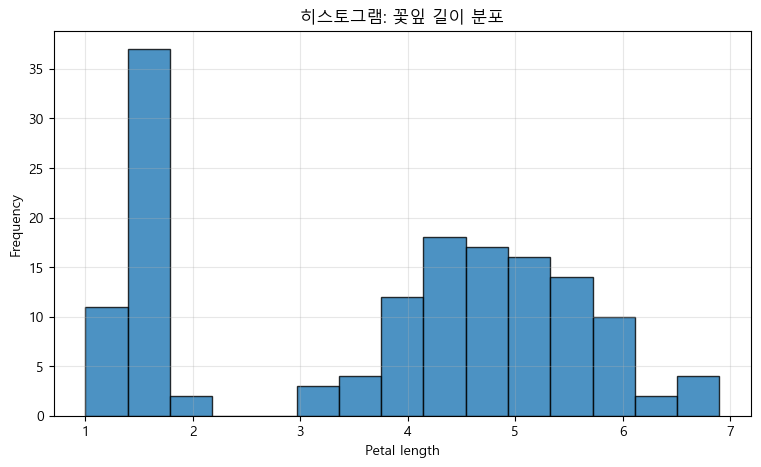

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

In [8]:
# ------------------------------------------------------------
# 히스토그램: 하나의 수치형 변수 분포 확인
# ------------------------------------------------------------
# 의미:
# - 히스토그램은 하나의 변수 X가 가질 수 있는 값의 구간을 여러 개로 나눕니다.
# - 각 구간에 속하는 데이터 개수를 막대 높이로 표현합니다.
# - 데이터 세트를 이해하는 첫 단계로 자주 사용됩니다.
# - bins 값을 키우면 구간을 더 촘촘하게 나누고, 줄이면 더 넓게 나눕니다.
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.hist(iris["petal_length"], bins=15, edgecolor="black", alpha=0.8)

plt.title("히스토그램: 꽃잎 길이 분포")
plt.xlabel("Petal length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(iris["petal_length"].describe())

## 히스토그램 해석 질문

1. 꽃잎 길이는 하나의 봉우리처럼 보이나요, 여러 그룹으로 나뉘어 보이나요?
2. 데이터가 많이 몰려 있는 구간은 어디인가요?
3. `bins` 값을 5, 30으로 바꾸면 해석이 어떻게 달라지나요?

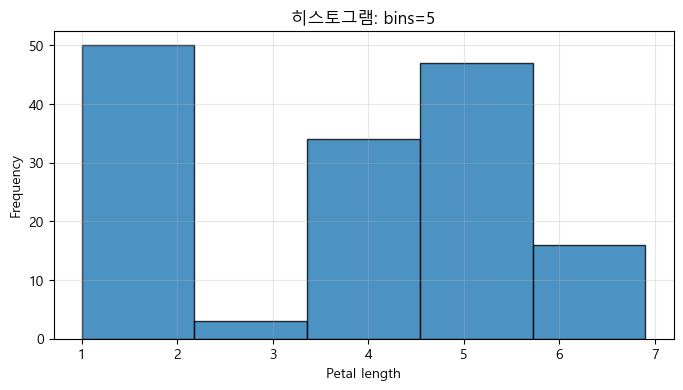

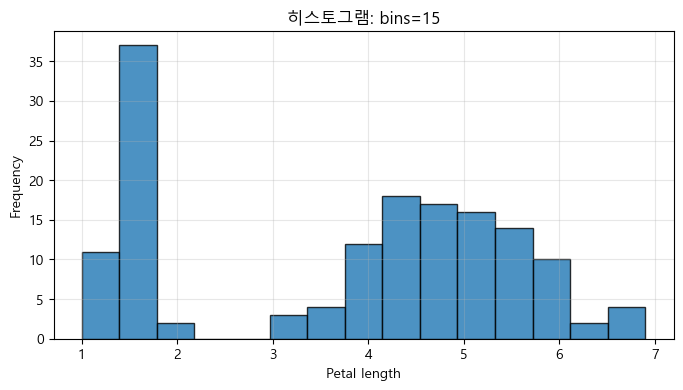

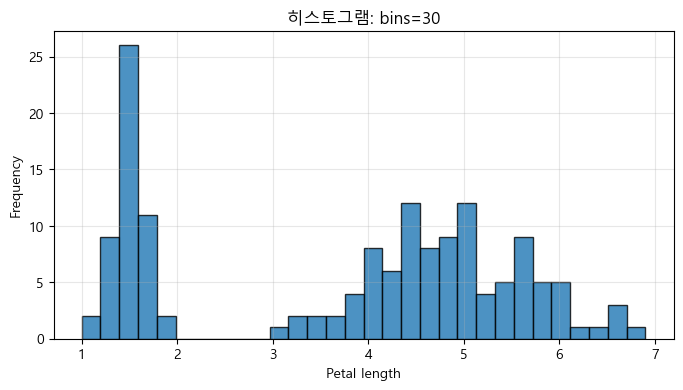

In [9]:
# ------------------------------------------------------------
# 실습: bins 값에 따른 히스토그램 변화 비교
# ------------------------------------------------------------
# 의미:
# - bins는 히스토그램에서 구간의 개수를 의미합니다.
# - bins가 작으면 전체적인 분포를 단순하게 볼 수 있고,
#   bins가 크면 세부적인 분포를 더 촘촘하게 볼 수 있습니다.
# ------------------------------------------------------------

for bins in [5, 15, 30]:
    plt.figure(figsize=(8, 4))
    plt.hist(iris["petal_length"], bins=bins, edgecolor="black", alpha=0.8)
    plt.title(f"히스토그램: bins={bins}")
    plt.xlabel("Petal length")
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# 7. 산점도(Scatter Plot)

## 의미

산점도는 **2개의 1차원 데이터 묶음 간의 관계**를 나타내고자 할 때 유용한 그래프입니다.

라인 그래프나 바 그래프는 보통 X가 변함에 따라 Y가 어떻게 변화하는지 보는 데 목적이 있습니다. 반면 산점도는 서로 다른 두 수치형 변수 X1, X2 사이에 어떤 관계가 있는지를 확인할 때 많이 사용합니다.

이번 실습에서는 `iris.data`의 꽃잎 길이(`petal_length`)와 꽃잎 너비(`petal_width`)의 관계를 확인합니다.

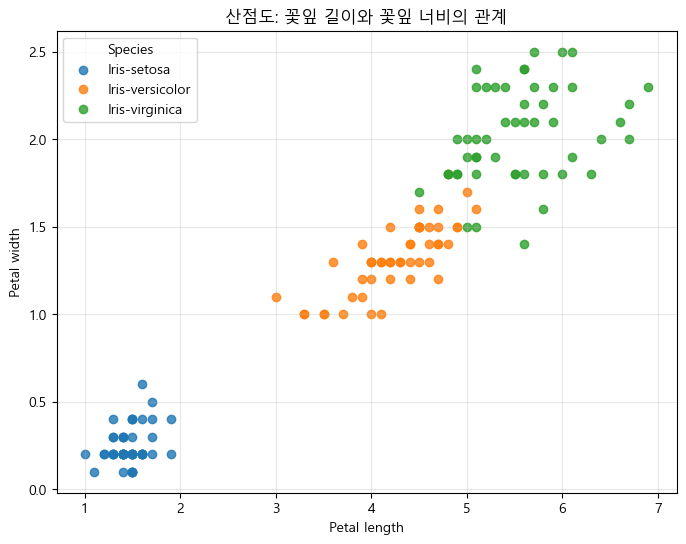

In [10]:
# ------------------------------------------------------------
# 산점도: 두 수치형 변수 사이의 관계 확인
# ------------------------------------------------------------
# 의미:
# - 산점도는 2개의 1차원 데이터 묶음 간의 관계를 나타내고자 할 때 유용합니다.
# - 각 관측치는 x축 값과 y축 값을 가진 하나의 점으로 표현됩니다.
# - 여기서는 꽃잎 길이와 꽃잎 너비가 함께 증가하는 관계인지 확인합니다.
# - 품종별로 점을 구분하면 두 변수 관계가 품종에 따라 어떻게 다른지도 볼 수 있습니다.
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for species_name, group in iris.groupby("species"):
    plt.scatter(
        group["petal_length"],
        group["petal_width"],
        label=species_name,
        alpha=0.8
    )

plt.title("산점도: 꽃잎 길이와 꽃잎 너비의 관계")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(title="Species")
plt.grid(True, alpha=0.3)
plt.show()

## 산점도 해석 질문

1. 꽃잎 길이가 길수록 꽃잎 너비도 커지는 경향이 있나요?
2. 품종별로 점들이 서로 잘 구분되나요?
3. 산점도만 보고도 분류 모델이 어느 정도 가능할 것 같나요?

# 8. 원형 차트(Pie Chart)

## 의미

원형 차트는 **전체에서 각 범주가 차지하는 비율**을 보여줄 때 사용합니다.

단, 원형 차트는 범주가 너무 많거나 값의 차이가 작으면 해석이 어려울 수 있습니다. 따라서 소수의 범주가 전체를 어떻게 나누는지 보여줄 때 적합합니다.

이번 실습에서는 `iris.data`에서 품종별 데이터 개수 비율을 확인합니다.

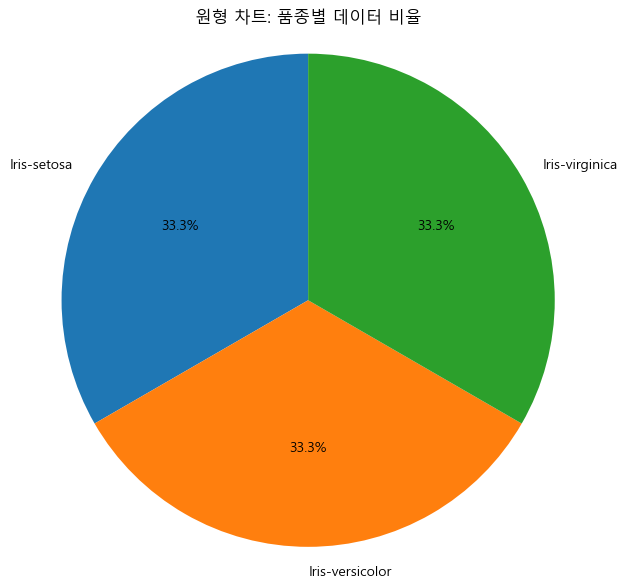

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [11]:
# ------------------------------------------------------------
# 원형 차트: 전체에서 각 범주가 차지하는 비율 확인
# ------------------------------------------------------------
# 의미:
# - 원형 차트는 전체를 100%로 보았을 때 각 범주가 차지하는 비율을 확인할 때 사용합니다.
# - 여기서는 전체 iris 데이터 중 각 품종이 몇 %를 차지하는지 확인합니다.
# - 범주가 너무 많으면 원형 차트보다 바 그래프가 더 적합할 수 있습니다.
# ------------------------------------------------------------

species_counts = iris["species"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    species_counts.values,
    labels=species_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("원형 차트: 품종별 데이터 비율")
plt.axis("equal")  # 원을 찌그러지지 않게 표시합니다.
plt.show()

display(species_counts.to_frame("count"))

## 원형 차트 해석 질문

1. 세 품종의 비율은 균등한가요?
2. 이 데이터에서는 원형 차트가 읽기 쉬운 편인가요?
3. 범주가 10개 이상이라면 원형 차트와 바 그래프 중 무엇이 더 적합할까요?

# 9. 히트맵(Heatmap)

## 의미

히트맵은 **2차원 행렬 형태의 값**을 색상으로 표현하는 그래프입니다.

데이터 분석에서는 변수 간 상관관계 행렬을 시각화할 때 자주 사용합니다. 색이 진하거나 값이 클수록 두 변수 간 관계가 강하다고 해석할 수 있습니다.

이번 실습에서는 `iris.data`의 수치형 변수들 간 상관계수를 히트맵으로 나타냅니다.

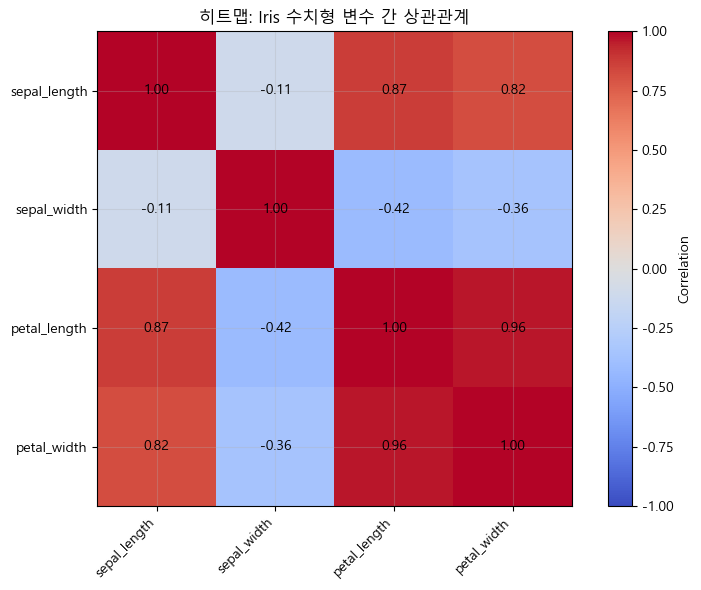

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [12]:
# ------------------------------------------------------------
# 히트맵: 상관관계 행렬 시각화
# ------------------------------------------------------------
# 의미:
# - 히트맵은 2차원 행렬 데이터를 색상으로 표현할 때 사용합니다.
# - 여기서는 수치형 변수 간 상관계수(correlation coefficient)를 계산합니다.
# - 상관계수는 -1에서 1 사이의 값을 가지며,
#   1에 가까우면 함께 증가, -1에 가까우면 한쪽이 증가할 때 다른 쪽은 감소하는 경향을 의미합니다.
# - 대각선은 자기 자신과의 상관관계이므로 항상 1입니다.
# ------------------------------------------------------------

numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
corr = iris[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# Matplotlib만 사용하여 heatmap을 그립니다.
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

# 축 눈금과 라벨 설정
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

# 각 칸에 상관계수 값을 표시합니다.
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

ax.set_title("히트맵: Iris 수치형 변수 간 상관관계")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

display(corr)

## 히트맵 해석 질문

1. 가장 강한 양의 상관관계를 보이는 변수 쌍은 무엇인가요?
2. 상관관계가 낮거나 음수에 가까운 변수 쌍은 무엇인가요?
3. 산점도와 히트맵은 각각 어떤 장점이 있나요?

# 10. 그래프 유형별 선택 기준 정리

아래 표는 실무에서 어떤 그래프를 선택해야 하는지 판단할 때 사용할 수 있는 기준입니다.

In [13]:
# 그래프 선택 기준을 DataFrame으로 정리합니다.
chart_guide = pd.DataFrame({
    "그래프": ["라인 그래프", "바 그래프", "히스토그램", "산점도", "원형 차트", "히트맵"],
    "적합한 질문": [
        "시간이 지나며 값이 어떻게 변하는가?",
        "범주별 값의 크기가 어떻게 다른가?",
        "하나의 수치형 변수는 어떤 분포를 가지는가?",
        "두 수치형 변수 사이에 관계가 있는가?",
        "전체에서 각 범주가 차지하는 비율은 얼마인가?",
        "2차원 행렬 값 또는 변수 간 관계 구조는 어떠한가?"
    ],
    "이번 실습 예시": [
        "날짜별 주가 변화",
        "품종별 평균 꽃잎 길이",
        "꽃잎 길이 분포",
        "꽃잎 길이와 꽃잎 너비의 관계",
        "품종별 데이터 비율",
        "Iris 변수 간 상관관계"
    ]
})

display(chart_guide)

,그래프,적합한 질문,이번 실습 예시
0,라인 그래프,시간이 지나며 값이 어떻게 변하는가?,날짜별 주가 변화
1,바 그래프,범주별 값의 크기가 어떻게 다른가?,품종별 평균 꽃잎 길이
2,히스토그램,하나의 수치형 변수는 어떤 분포를 가지는가?,꽃잎 길이 분포
3,산점도,두 수치형 변수 사이에 관계가 있는가?,꽃잎 길이와 꽃잎 너비의 관계
4,원형 차트,전체에서 각 범주가 차지하는 비율은 얼마인가?,품종별 데이터 비율
5,히트맵,2차원 행렬 값 또는 변수 간 관계 구조는 어떠한가?,Iris 변수 간 상관관계


# 11. 종합 실습 문제

아래 문제를 직접 풀어보세요.

## 문제 1
`stock` 데이터에서 하나의 종목을 선택하고, 일별 가격과 30일 이동평균을 라인 그래프로 함께 그려보세요.

## 문제 2
`iris` 데이터에서 품종별 평균 `sepal_length`를 바 그래프로 그려보세요.

## 문제 3
`iris` 데이터에서 `sepal_width`의 히스토그램을 그려보고, `bins` 값을 바꿔보세요.

## 문제 4
`iris` 데이터에서 `sepal_length`와 `petal_length`의 산점도를 그리고 품종별로 색을 다르게 표현해보세요.

## 문제 5
`iris` 데이터에서 품종별 개수 비율을 원형 차트로 그려보세요.

## 문제 6
`iris` 데이터의 수치형 변수 중 원하는 변수 3개 이상을 선택하여 상관관계 히트맵을 그려보세요.

# 12. 종합 실습 문제 풀이 예시

아래 코드는 한 가지 풀이 예시입니다. 먼저 직접 풀어본 뒤 확인하는 것을 권장합니다.

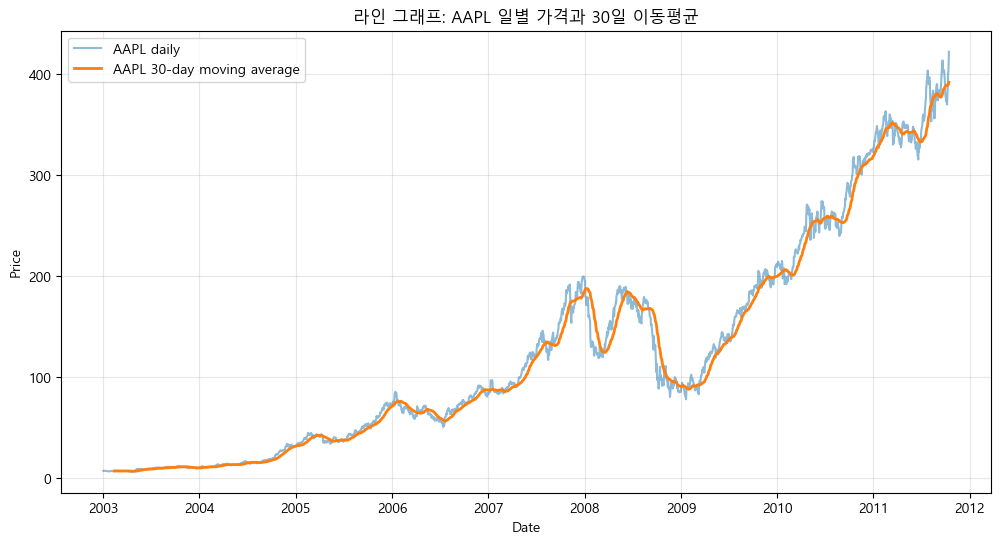

In [14]:
# ------------------------------------------------------------
# 문제 1 풀이 예시: 일별 가격과 30일 이동평균 라인 그래프
# ------------------------------------------------------------
# 의미:
# - 원본 가격은 짧은 기간의 변동이 크고,
# - 이동평균은 전체 추세를 더 부드럽게 보여줍니다.
# ------------------------------------------------------------

target_col = "AAPL" if "AAPL" in stock.columns else stock.columns[0]

plt.figure(figsize=(12, 6))
plt.plot(stock.index, stock[target_col], label=f"{target_col} daily", alpha=0.5)
plt.plot(stock.index, stock[target_col].rolling(30).mean(), label=f"{target_col} 30-day moving average", linewidth=2)

plt.title(f"라인 그래프: {target_col} 일별 가격과 30일 이동평균")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

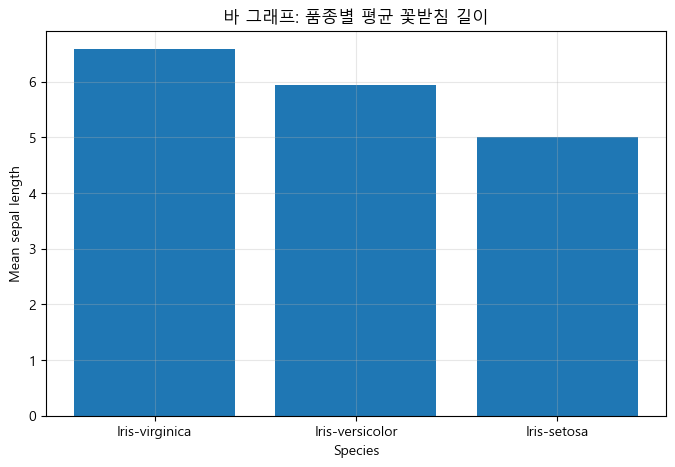

In [15]:
# ------------------------------------------------------------
# 문제 2 풀이 예시: 품종별 평균 꽃받침 길이 바 그래프
# ------------------------------------------------------------
# 의미:
# - 서로 다른 품종이라는 범주별 평균값을 비교하므로 바 그래프가 적합합니다.
# ------------------------------------------------------------

species_sepal_mean = iris.groupby("species")["sepal_length"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(species_sepal_mean.index, species_sepal_mean.values)
plt.title("바 그래프: 품종별 평균 꽃받침 길이")
plt.xlabel("Species")
plt.ylabel("Mean sepal length")
plt.grid(axis="y", alpha=0.3)
plt.show()

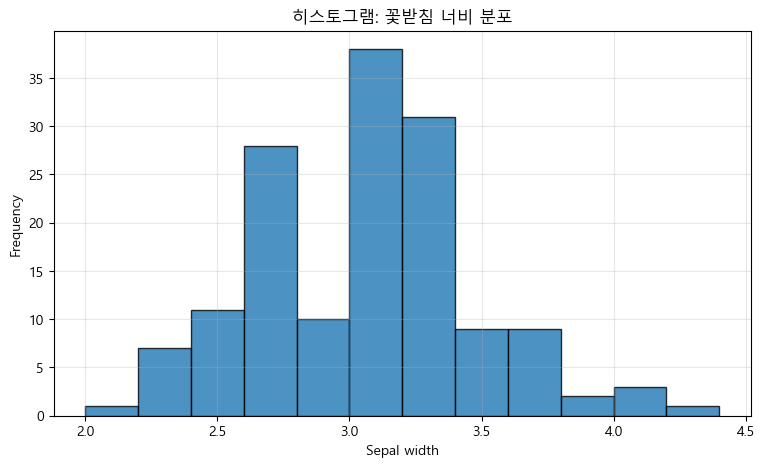

In [16]:
# ------------------------------------------------------------
# 문제 3 풀이 예시: 꽃받침 너비 히스토그램
# ------------------------------------------------------------
# 의미:
# - 하나의 변수(sepal_width)가 어떤 값 범위에 많이 분포하는지 확인합니다.
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.hist(iris["sepal_width"], bins=12, edgecolor="black", alpha=0.8)
plt.title("히스토그램: 꽃받침 너비 분포")
plt.xlabel("Sepal width")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

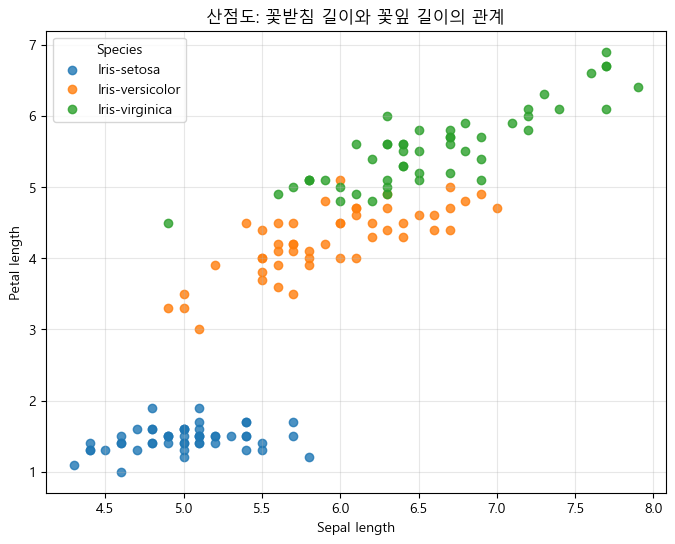

In [17]:
# ------------------------------------------------------------
# 문제 4 풀이 예시: 꽃받침 길이와 꽃잎 길이 산점도
# ------------------------------------------------------------
# 의미:
# - 두 수치형 변수 사이의 관계를 점으로 표현합니다.
# - 품종별 색을 다르게 하면 관계와 범주 구분을 동시에 볼 수 있습니다.
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for species_name, group in iris.groupby("species"):
    plt.scatter(
        group["sepal_length"],
        group["petal_length"],
        label=species_name,
        alpha=0.8
    )

plt.title("산점도: 꽃받침 길이와 꽃잎 길이의 관계")
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.legend(title="Species")
plt.grid(True, alpha=0.3)
plt.show()

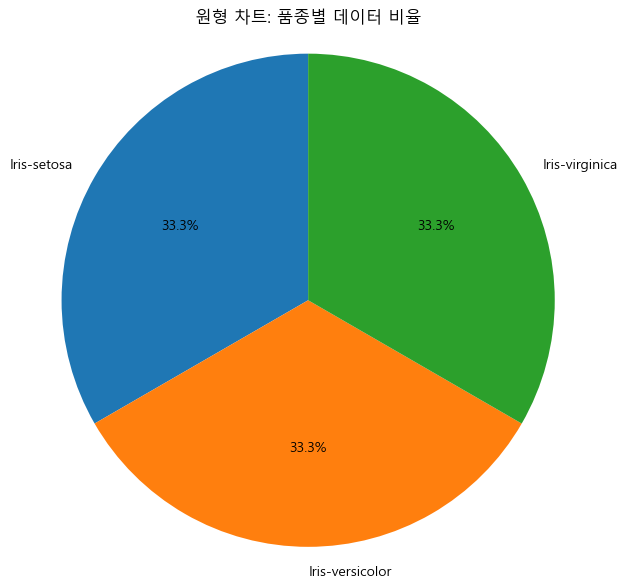

In [18]:
# ------------------------------------------------------------
# 문제 5 풀이 예시: 품종별 비율 원형 차트
# ------------------------------------------------------------
# 의미:
# - 전체 데이터 중 각 품종이 차지하는 비율을 확인합니다.
# ------------------------------------------------------------

species_counts = iris["species"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(species_counts, labels=species_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("원형 차트: 품종별 데이터 비율")
plt.axis("equal")
plt.show()

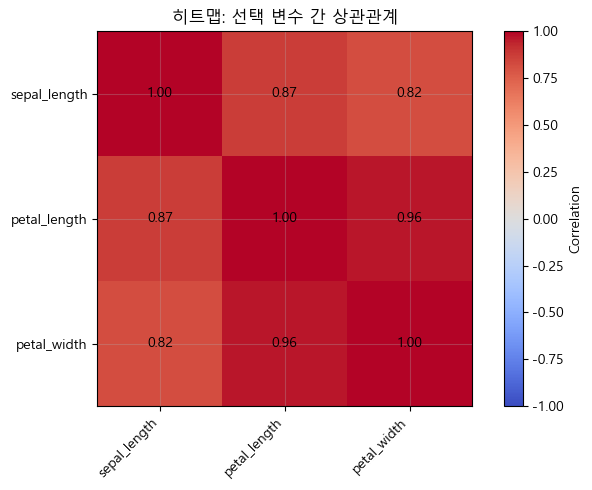

In [19]:
# ------------------------------------------------------------
# 문제 6 풀이 예시: 선택 변수 상관관계 히트맵
# ------------------------------------------------------------
# 의미:
# - 여러 변수 간 관계를 한눈에 비교할 수 있습니다.
# ------------------------------------------------------------

selected_cols = ["sepal_length", "petal_length", "petal_width"]
selected_corr = iris[selected_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(selected_corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(selected_cols)))
ax.set_yticks(np.arange(len(selected_cols)))
ax.set_xticklabels(selected_cols, rotation=45, ha="right")
ax.set_yticklabels(selected_cols)

for i in range(len(selected_cols)):
    for j in range(len(selected_cols)):
        ax.text(j, i, f"{selected_corr.values[i, j]:.2f}", ha="center", va="center")

ax.set_title("히트맵: 선택 변수 간 상관관계")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

# 13. 그래프 저장 예제

실무에서는 분석 결과를 보고서나 발표자료에 넣기 위해 그래프를 이미지 파일로 저장하는 경우가 많습니다.

Matplotlib에서는 `savefig()`를 사용하여 `.png`, `.pdf`, `.svg` 등 다양한 형식으로 저장할 수 있습니다.

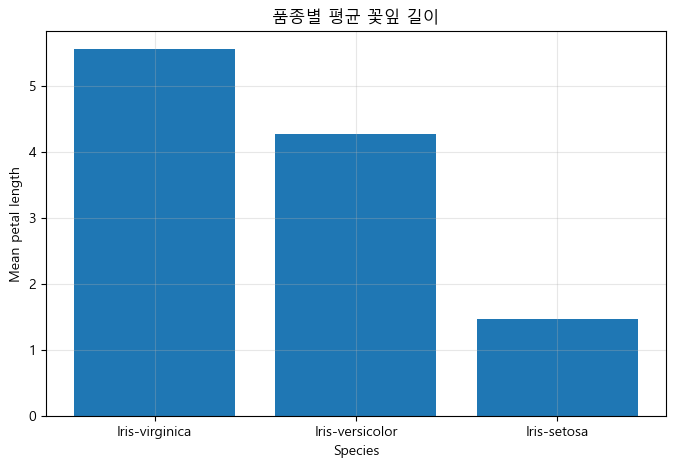

그래프가 저장되었습니다: iris_species_petal_length_bar.png


In [20]:
# ------------------------------------------------------------
# 그래프 저장 예제
# ------------------------------------------------------------
# 의미:
# - savefig()를 사용하면 현재 Figure를 이미지 파일로 저장할 수 있습니다.
# - dpi는 이미지 해상도입니다.
# - bbox_inches="tight"는 그래프 주변 여백을 줄여줍니다.
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(species_petal_mean.index, species_petal_mean.values)
plt.title("품종별 평균 꽃잎 길이")
plt.xlabel("Species")
plt.ylabel("Mean petal length")
plt.grid(axis="y", alpha=0.3)

output_image = "iris_species_petal_length_bar.png"
plt.savefig(output_image, dpi=150, bbox_inches="tight")
plt.show()

print(f"그래프가 저장되었습니다: {output_image}")

# 14. 마무리

이번 실습에서 배운 핵심은 다음과 같습니다.

1. **라인 그래프**: 시간 흐름, 순서가 있는 X축의 변화 추세
2. **바 그래프**: 범주별 값 비교
3. **히스토그램**: 하나의 수치형 변수 분포 확인
4. **산점도**: 두 수치형 변수 사이의 관계 확인
5. **원형 차트**: 전체 대비 범주별 비율 확인
6. **히트맵**: 2차원 행렬 값 또는 변수 간 상관관계 구조 확인

그래프 선택은 도구의 문제가 아니라 **분석 질문에 맞는 표현 방식을 선택하는 문제**입니다.